In [1]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Input, mixed_precision
from sklearn.model_selection import train_test_split
import cv2
import keras
print("library loaded successfully")
print("*"*100)

I0000 00:00:1779933304.177184   42824 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


library loaded successfully
****************************************************************************************************


In [2]:
IMG_SIZE = 256  # Standardized input resolution for both phases
BATCH_SIZE = 4 # Batch size
EPOCHS_PHASE1 = 150  # Semantic Segmentation Focus, for Segmentation 
EPOCHS_PHASE2 = 100   # Segmentation-Based Classification Focus for classification Polyp and Non-Polyp

#### Declaring dataset path for segmentation and classification

In [3]:
# Directory and Artifact Paths
DATA_PATH = '/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2'
POSITIVE_DIR = os.path.join(DATA_PATH, 'imagesAll_positive') # For Polyp classification
NEGATIVE_DIR = os.path.join(DATA_PATH, 'sequenceData/negativeOnly')  # For non polyp classification
MODEL_SAVE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/SC/unified_net/thesis_v3_sequential_28_5_02_ds_a_.keras"

#### mixed_precision
Activate mixed precision training for efficiency and memory optimization
It is a performance optimization for GPU. It utilize half of the GPU Memory, 
increases the the model training speed 3 times without effecting on accuracy. 
mixed_float16, 16 bits helps to get speedy calculation when need, Flawless accuracy performed by 32-bits

In [4]:

mixed_precision.set_global_policy('mixed_float16')

#### Image Augmentation
As we have limited datasources we have to augment images. If we train with limited datasets Model can memorize 
instead of learning which causes overfitting. An overfitted model cannot predict other image except training dataset. Even it cannot predict on validation dataset as well.The **overfitting occurs** when The Training Loss going down but the validation loss increases at a time

In [5]:

def augment(img, mask):
    """Applies shape-preserving geometric and radiometric transformations."""
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

#### Data / Image pre-processing pipeline for segmentation
This functions primary task is to load raw images corresponding its mask image from the file storage, clean them up, standardizing the image size finally convert them into clean tensor ( or a 2D matrix) suitable for the model to be trained.


In [6]:
# def process_path_segmentation(img_path, mask_path):
#     """
#     Advanced Preprocessing Wrapper for Dataset B.
#     Applies CLAHE and Mild Sharpening via OpenCV with strict EagerTensor handles.
#     """
#     def _read_and_process(img_p, mask_p):
#         img_p_str = img_p.numpy().decode('utf-8') if hasattr(img_p, 'numpy') else img_p.decode('utf-8')
#         mask_p_str = mask_p.numpy().decode('utf-8') if hasattr(mask_p, 'numpy') else mask_p.decode('utf-8')
        
#         img = cv2.imread(img_p_str)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
#         mask = cv2.imread(mask_p_str, cv2.IMREAD_GRAYSCALE)
#         mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        

#         lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#         l_channel, a_channel, b_channel = cv2.split(lab)
        
#         clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
#         cl = clahe.apply(l_channel)
        
#         limg = cv2.merge((cl, a_channel, b_channel))
#         enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        

#         gaussian_blur = cv2.GaussianBlur(enhanced_img, (5, 5), 1.0)
#         sharpened = cv2.addWeighted(enhanced_img, 1.5, gaussian_blur, -0.5, 0)
        
#         normalized_img = sharpened / 255.0
#         normalized_mask = mask / 255.0
#         normalized_mask = np.where(normalized_mask > 0.5, 1.0, 0.0)
        
#         normalized_mask = np.expand_dims(normalized_mask, axis=-1)
        
#         return normalized_img.astype(np.float32), normalized_mask.astype(np.float32)


#     [img_tensor, mask_tensor] = tf.py_function(
#         _read_and_process, 
#         [img_path, mask_path], 
#         [tf.float32, tf.float32]
#     )
    

#     img_tensor.set_shape([IMG_SIZE, IMG_SIZE, 3])
#     mask_tensor.set_shape([IMG_SIZE, IMG_SIZE, 1])
    
#     return img_tensor, mask_tensor
# def process_path_segmentation(img_path, mask_path):
#     """
#     Advanced Preprocessing Wrapper for Dataset B.
#     Applies CLAHE and Mild Sharpening via OpenCV with Median Blur (Edge-Preserving).
#     """
#     def _read_and_process(img_p, mask_p):
#         img_p_str = img_p.numpy().decode('utf-8') if hasattr(img_p, 'numpy') else img_p.decode('utf-8')
#         mask_p_str = mask_p.numpy().decode('utf-8') if hasattr(mask_p, 'numpy') else mask_p.decode('utf-8')
        
#         img = cv2.imread(img_p_str)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
#         mask = cv2.imread(mask_p_str, cv2.IMREAD_GRAYSCALE)
#         mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        
#         # ─── STEP 1: CONTRAST ENHANCEMENT (CLAHE) ───
#         lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#         l_channel, a_channel, b_channel = cv2.split(lab)
        
#         clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
#         cl = clahe.apply(l_channel)
        
#         limg = cv2.merge((cl, a_channel, b_channel))
#         enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        
#         # ─── STEP 2: EDGE-PRESERVING NOISE REDUCTION (MEDIAN BLUR) ───
#         median_blur = cv2.medianBlur(enhanced_img, 5)
        
#         # ─── STEP 3: MILD SHARPENING ───
#         sharpened = cv2.addWeighted(enhanced_img, 1.5, median_blur, -0.5, 0)
        
#         # ─── STEP 4: NORMALIZATION ───
#         normalized_img = sharpened / 255.0
#         normalized_mask = mask / 255.0
#         normalized_mask = np.where(normalized_mask > 0.5, 1.0, 0.0)
        
#         normalized_mask = np.expand_dims(normalized_mask, axis=-1)
        
#         return normalized_img.astype(np.float32), normalized_mask.astype(np.float32)

#     [img_tensor, mask_tensor] = tf.py_function(
#         _read_and_process, 
#         [img_path, mask_path], 
#         [tf.float32, tf.float32]
#     )
    
#     img_tensor.set_shape([IMG_SIZE, IMG_SIZE, 3])
#     mask_tensor.set_shape([IMG_SIZE, IMG_SIZE, 1])
    
#     return img_tensor, mask_tensor

In [7]:
import random

def process_path_segmentation(img_path, mask_path):
    """
    Advanced Preprocessing Wrapper for Dataset B.
    Applies CLAHE, Median Blur, Mild Sharpening, and Coarse Dropout.
    """
    def _read_and_process(img_p, mask_p):
        img_p_str = img_p.numpy().decode('utf-8') if hasattr(img_p, 'numpy') else img_p.decode('utf-8')
        mask_p_str = mask_p.numpy().decode('utf-8') if hasattr(mask_p, 'numpy') else mask_p.decode('utf-8')
        
        img = cv2.imread(img_p_str)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        mask = cv2.imread(mask_p_str, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        
        # ─── STEP 1: CONTRAST ENHANCEMENT (CLAHE) ───
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)
        
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        cl = clahe.apply(l_channel)
        
        limg = cv2.merge((cl, a_channel, b_channel))
        enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        median_blur = cv2.medianBlur(enhanced_img, 3) 
        
        # ─── STEP 3: MILD SHARPENING ───
        sharpened = cv2.addWeighted(enhanced_img, 1.5, median_blur, -0.5, 0)
        
        """ 
        # Coarse Dropout
        if random.random() < 0.5:
            block_size = 32 
            x = random.randint(0, IMG_SIZE - block_size)
            y = random.randint(0, IMG_SIZE - block_size)
            sharpened[y:y+block_size, x:x+block_size, :] = 0  
            mask[y:y+block_size, x:x+block_size] = 0         
        """
        # ─── STEP 4: NORMALIZATION ───
        normalized_img = sharpened / 255.0
        normalized_mask = mask / 255.0
        normalized_mask = np.where(normalized_mask > 0.5, 1.0, 0.0)
        
        normalized_mask = np.expand_dims(normalized_mask, axis=-1)
        
        return normalized_img.astype(np.float32), normalized_mask.astype(np.float32)

    [img_tensor, mask_tensor] = tf.py_function(
        _read_and_process, 
        [img_path, mask_path], 
        [tf.float32, tf.float32]
    )
    
    img_tensor.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask_tensor.set_shape([IMG_SIZE, IMG_SIZE, 1])
    
    return img_tensor, mask_tensor

#### Data / Image Pre-processing for classification
getting the image and label wheather it is polyp or not, also converting the image for standardization

In [8]:
def process_path_classification(img_path, label):
    """Preprocesses input tensors and categorical targets for Dataset A."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label

#### Load Segmentation data path
Instead of loading the actual images into memory, it loads the images path dynamically, 
The image is only collected for segmentation training, it it's exact mask match in the dataset directory.

In [9]:
def load_segmentation_paths(base_path):
    """Extracts paired image and mask absolute paths from multi-center repositories."""
    all_images, all_masks = [], []
    for i in range(1, 7):
        center_id = f"C{i}"
        img_dir = os.path.join(base_path, f"data_{center_id}", f"images_{center_id}")
        mask_dir = os.path.join(base_path, f"data_{center_id}", f"masks_{center_id}")
        if os.path.exists(img_dir) and os.path.exists(mask_dir):
            img_paths = (glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.JPG")) +
                         glob.glob(os.path.join(img_dir, "*.png")) + glob.glob(os.path.join(img_dir, "*.jpeg")))
            for img_p in img_paths:
                filename = os.path.basename(img_p)
                name_without_ext, ext = os.path.splitext(filename)
                expected_mask_name = f"{name_without_ext}_mask{ext}"
                mask_p = os.path.join(mask_dir, expected_mask_name)
                if os.path.exists(mask_p):
                    all_images.append(img_p)
                    all_masks.append(mask_p)
    return all_images, all_masks

#### Load Classification data path
this function labels the images into two classes -0 for Negative image or Non-Polyp and 1 for Positive image or Polyp
**Note:** When your dataset has 90% negative and 10% positive, highly imbalance dataset it creates a cheat code to get high accuracy. thus it causes a Accuracy Paradox, and for this reason it misclassify the image. 

In [10]:
def load_classification_paths():
    """Compiles absolute paths for global positive and artifact-heavy negative sequences."""
    valid_exts = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.PNG', '*.JPG', '*.JPEG')
    pos_files, neg_files = [], []
    for ext in valid_exts:
        pos_files.extend(glob.glob(os.path.join(POSITIVE_DIR, "**", ext), recursive=True))
    for i in range(1, 14):
        target_folder = os.path.join(NEGATIVE_DIR, f"seq{i}_neg")
        if os.path.exists(target_folder):
            for ext in valid_exts:
                neg_files.extend(glob.glob(os.path.join(target_folder, "**", ext), recursive=True))
    pos_files = [f for f in pos_files if os.path.isfile(f)]
    neg_files = [f for f in neg_files if os.path.isfile(f)]
    
    file_paths = pos_files + neg_files
    labels = [1.0] * len(pos_files) + [0.0] * len(neg_files)
    return np.array(file_paths), np.array(labels, dtype=np.float32)

#### Squeeze-and-Excitation Block
To get channel-wise attention it is very much powerful for CNN. An SE_Block dynamically learns which channel/features are the most important for a specific image and scale up the specific features with dimming down the noise with irrelevent ones.
Standard CNN only looks at the small neighbour of the pixel at a time, But GlobalAveragePooling2D gets the average value of pixels.  from the total height and weight of a channel.  
__How Squeeze works:__  
We can consider an image with a 3D feature map, as it has three distinct geometric dimentions: Height, Width and Depth (Channels). 
Image Height (H) : Vertical Pixels (256 pixels height)
Image Width (W) : Horizontal Pixels (256 pixels width)
Channels (C): The depth layer, this is 3 (RGB)
So an image has a 3D block dimentions = 256x256x3. 
When an image passes through convolutional layers, the spatial dimentions (H and W) usually shrink, but the number of channels (C) expands dramatically, Deep in your network you might have a feature map of size 16x16x512 that is a literal 3D cube made of 131,072 numarial values.
** The Sqeeze Turns 3D into 1D** ```layers.GlobalAveragePooling2D()(input_tensor)``` this sentence takes the 3D Cube and flattens its spatial dimentions. 

```sh
3D CUBE[16x16x512] -----Global Average Pooling------> 1D vector [512]

Before Squeeze (3D Cube):
       _______
      /      /|
     /______/ |  <- 512 separate 16x16 slices stacked deep
    |       | |
    |_______|/
  16x16 spatial grid

After Squeeze (1D Array/Vector):
    [ 0.78,  0.12,  0.91,  0.03, ... , 0.55 ]  <- Exactly 512 numbers long
```
__How Excitation Works:__  
Excitation works with 3 steps. 
1. (512-->32) Make the flatten array smaller from 512 to 32 by removing the noices and connecting the relation between hidden relations.
2. Employee ReLU filter: negative or week features are converted to 0
3. (32-->512) Revert the process.


In [11]:
def se_block(input_tensor, ratio=16):
    """Channel-wise Squeeze-and-Excitation Attention Layer."""
    channels = input_tensor.shape[-1]
    squeeze = layers.GlobalAveragePooling2D()(input_tensor)
    excitation = layers.Dense(channels // ratio, activation='relu', use_bias=False)(squeeze)
    excitation = layers.Dense(channels, activation='sigmoid', use_bias=False)(excitation)
    excitation = layers.Reshape((1, 1, channels))(excitation)
    return layers.multiply([input_tensor, excitation])

#### depthwise_separable_conv_block
Instead of using Conv2D block, we integrated Depthwise Separable for optimizing the operation.

In [12]:
def depthwise_seperable_conv_block(x, filters, dropout_rate=0.0, name_prefix=""):
    """Multi-Scale Parallel Kernels (3x3, 5x5, 7x7, 1x1) with Depthwise Separable Convolutions."""
    f4 = filters // 4
    b3 = layers.SeparableConv2D(f4, 3, padding='same', use_bias=False, name=f"{name_prefix}_3x3")(x)
    b3 = layers.BatchNormalization()(b3); b3 = layers.Activation('relu')(b3)
    
    b5 = layers.SeparableConv2D(f4, 5, padding='same', use_bias=False, name=f"{name_prefix}_5x5")(x)
    b5 = layers.BatchNormalization()(b5); b5 = layers.Activation('relu')(b5)
    
    b7 = layers.SeparableConv2D(f4, 7, padding='same', use_bias=False, name=f"{name_prefix}_7x7")(x)
    b7 = layers.BatchNormalization()(b7); b7 = layers.Activation('relu')(b7)
    
    b1 = layers.SeparableConv2D(f4, 1, padding='same', use_bias=False, name=f"{name_prefix}_1x1")(x)
    b1 = layers.BatchNormalization()(b1); b1 = layers.Activation('relu')(b1)
    
    merged = layers.Concatenate(name=f"{name_prefix}_concat")([b3, b5, b7, b1])
    x_se = se_block(merged, ratio=16) 
    # Feed-forward Network Integration
    if x.shape[-1] == filters:
        x_se = layers.add([x, x_se], name=f"{name_prefix}_residual")
    if dropout_rate > 0:
        x_se = layers.SpatialDropout2D(dropout_rate, name=f"{name_prefix}_dropout")(x_se)
    return x_se

#### Pearson Corelation Coefficient
As Global Average Pooling returns 1D feature vector, the relation can be found by employing PCC on this feature.
The first and formost condition is to standardize the feature before employing PCC on 1D feature vector.

In [13]:
@tf.keras.utils.register_keras_serializable()
class KerasPCCLayer(layers.Layer):
    """Natively computes spatial Pearson Correlation Coefficients within the network graph."""
    def __init__(self, **kwargs):
        super(KerasPCCLayer, self).__init__(**kwargs)

    def call(self, inputs):
        # We used epsilon sothat standard deviation value cannot be zero, otherwise code will crash
        epsilon = 1e-8
        # finds the average standard deviaiton
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        std = tf.math.reduce_std(inputs, axis=-1, keepdims=True) + epsilon
        # data normalization or (Z-Score)
        norm_inputs = (inputs - mean) / std
        pcc_matrix = tf.matmul(tf.expand_dims(norm_inputs, -1), tf.expand_dims(norm_inputs, 1))
        return layers.Flatten()(pcc_matrix)

#### Build Unified Segmentation based Model
A multi-task Y-Net model building for both segmentation and classification for Colorectal Polyp.


In [14]:
def build_unified_segmentation_based_model(input_shape=(256, 256, 3)):
    """
    Constructs a dual-headed multi-task Y-Net architecture.
    Shares a deeply regularized, multi-scale latent space to simultaneously
    perform semantic image segmentation and unified scene classification.
    Integrated with Deep Supervision along the decoder pathway for SOTA convergence.
    """
    # [Input Layer]: Defines the input tensor shape holding the raw 3-channel RGB medical images.
    inputs = Input(shape=input_shape, name="shared_input_image")

    # ── Shared Custom Multi-Scale Encoder ─────────────────────────────────────
    # [Enc Block 1]: Processes raw input into 32 multi-scale feature channels. Output dim: (256, 256, 32)
    c1 = depthwise_seperable_conv_block(inputs, 32, name_prefix="enc_c1")
    # [Max Pooling 1]: Downsamples spatial dimensions by a factor of 2. Dim: (128, 128, 32)
    p1 = layers.MaxPooling2D(2, name="enc_p1")(c1)

    # [Enc Block 2]: Extracts deeper geometric abstractions into 64 semantic channels. Output dim: (128, 128, 64)
    c2 = depthwise_seperable_conv_block(p1, 64, name_prefix="enc_c2")
    # [Max Pooling 2]: Downsamples spatial dimensions further. Dim: (64, 64, 64)
    p2 = layers.MaxPooling2D(2, name="enc_p2")(c2)

    # [Enc Block 3]: Scales representation to 128 channels. Dim: (64, 64, 128)
    c3 = depthwise_seperable_conv_block(p2, 128, dropout_rate=0.1, name_prefix="enc_c3")
    # [Max Pooling 3]: Reduces resolution further. Dim: (32, 32, 128)
    p3 = layers.MaxPooling2D(2, name="enc_p3")(c3)

    # [Enc Block 4]: Captures high-level contextual abstracts across 256 channels. Dim: (32, 32, 256)
    c4 = depthwise_seperable_conv_block(p3, 256, dropout_rate=0.2, name_prefix="enc_c4")
    # [Max Pooling 4]: Compresses spatial grid to its lowest native encoder resolution. Dim: (16, 16, 256)
    p4 = layers.MaxPooling2D(2, name="enc_p4")(c4)
    
    # ── Shared Representation Latent Bottleneck ───────────────────────────────
    # [Shared Bottleneck]: Maps the compressed grid into a highly dense 512-channel latent feature space. Dim: (16, 16, 512)
    b = depthwise_seperable_conv_block(p4, 512, dropout_rate=0.3, name_prefix="shared_bottleneck")

    # ── Output Branch A: Semantic Segmentation Decoder with Deep Supervision ──
    # [Upsampling 4]: Uses learned transpose convolution filters to upscale the latent grid. Dim: (32, 32, 256)
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same', name="dec_u4")(b)
    # [Skip Connection 4]: Concatenates low-level encoder features (c4). Total channels: 256 + 256 = 512
    u4 = layers.concatenate([u4, c4], name="dec_concat_4")
    # [Dec Block 5]: Regularizes concatenated representation back to 256 optimized features. Dim: (32, 32, 256)
    c5 = depthwise_seperable_conv_block(u4, 256, dropout_rate=0.2, name_prefix="dec_c5")

    # Deep Supervision process integration
    ds1 = layers.Conv2D(1, 1, padding='same', name='ds1_conv')(c5)
    ds1 = layers.UpSampling2D(size=(8, 8), interpolation='bilinear', dtype='float32', name='ds1_output')(ds1)

    # [Upsampling 3]: Expands spatial dimensions. Dim: (64, 64, 128)
    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same', name="dec_u3")(c5)
    # [Skip Connection 3]: Merges encoder's mid-level details (c3). Total channels: 128 + 128 = 256
    u3 = layers.concatenate([u3, c3], name="dec_concat_3")
    # [Dec Block 6]: Consolidates features. Dim: (64, 64, 128)
    c6 = depthwise_seperable_conv_block(u3, 128, dropout_rate=0.1, name_prefix="dec_c6")

    # 🎯 [Deep Supervision 2]: c6 (64x64x128) থেকে ২য় সাহায্যকারী আউটপুট হেড তৈরি
    # ছবির ওরিজিনাল সাইজ ২৫৬ তে নিয়ে যাওয়ার জন্য ৪ গুণ (strides=4) আপস্যাম্পল করা হলো।
    ds2 = layers.Conv2D(1, 1, padding='same', name='ds2_conv')(c6)
    ds2 = layers.UpSampling2D(size=(4, 4), interpolation='bilinear', dtype='float32', name='ds2_output')(ds2)

    # [Upsampling 2]: Output dim: (128, 128, 64)
    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same', name="dec_u2")(c6)
    # [Skip Connection 2]: Re-introduces high-resolution textures from c2. Total channels: 64 + 64 = 128
    u2 = layers.concatenate([u2, c2], name="dec_concat_2")
    # [Dec Block 7]: Harmonizes maps into 64 channels. Dim: (128, 128, 64)
    c7 = depthwise_seperable_conv_block(u2, 64, name_prefix="dec_c7")

    # 🎯 [Deep Supervision 3]: c7 (128x128x64) থেকে ৩য় সাহায্যকারী আউটপুট হেড তৈরি
    # ছবির ওরিজিনাল সাইজ ২৫৬ তে নিয়ে যাওয়ার জন্য ২ গুণ (strides=2) আপস্যাম্পল করা হলো।
    ds3 = layers.Conv2D(1, 1, padding='same', name='ds3_conv')(c7)
    ds3 = layers.UpSampling2D(size=(2, 2), interpolation='bilinear', dtype='float32', name='ds3_output')(ds3)

    # [Upsampling 1]: Restores feature maps back to the original input spatial size. Output dim: (256, 256, 32)
    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same', name="dec_u1")(c7)
    # [Skip Connection 1]: Concat-links raw spatial coordinates directly from c1. Total channels: 32 + 32 = 64
    u1 = layers.concatenate([u1, c1], name="dec_concat_1")
    # [Dec Block 8]: Refines final decoded features. Dim: (256, 256, 32)
    c8 = depthwise_seperable_conv_block(u1, 32, name_prefix="dec_c8")

    # [Main Segmentation Mask Output]: ওরিজিনাল ফাইনাল আউটপুট
    segmentation_output = layers.Conv2D(1, 1, activation='sigmoid', dtype='float32', name='seg_output')(c8)

    # ── Output Branch B: Segmentation-Guided Classification Head ──────────────
    # [Classification CNN]: Performs light 3x3 depthwise separable convolution. Dim: (16, 16, 32)
    pd_cnn = layers.SeparableConv2D(32, (3, 3), padding='same', activation='relu', name="clf_pd_cnn")(b)
    # [Max Pooling]: Downsamples classification maps spatially. Output dim: (8, 8, 32)
    p_pool = layers.MaxPooling2D((2, 2), name="clf_maxpool")(pd_cnn)
    
    # [Global Average Pooling (GAP)]: Collapses spatial dimensions into a single vector.
    flat_features = layers.GlobalAveragePooling2D(name="clf_gap")(p_pool)
    # [Keras PCC Layer]: Computes Linear statistical dependency.
    pcc_features = KerasPCCLayer(name="clf_pcc_layer")(flat_features)
    # [Z-Score Normalization]: Stabilizes dense convergence.
    standardized = layers.BatchNormalization(name="clf_zscore_bn")(pcc_features)
    
    # [Fully Connected Dense]: Learns non-linear correlation.
    d1 = layers.Dense(64, activation='relu', name="clf_dense1")(standardized)
    # [Dropout]: Prevent Overfitting
    d1 = layers.Dropout(0.3, name="clf_dropout")(d1)
    # [Classification Score Output]: Yields global disease probability.
    classification_output = layers.Dense(1, activation='sigmoid', dtype='float32', name='clf_output')(d1)

    # ── [Model Compilation Graph Finalization] ────────────────────────────────
    return models.Model(
        inputs=inputs, 
        outputs=[segmentation_output, ds1, ds2, ds3, classification_output], 
        name="Thesis_DeepSupervised_YNet"
    )

#### Mathematical Criteria and Performance Metrics

#### Dice Coefficient
The most popular performance matrix for segmentation. the more close to 100% means the better performance.
Excellent dice Coef score between 0.8 to 0.9
Good Score 0.70 to 0.80

In [15]:
@keras.saving.register_keras_serializable()
def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


In [16]:
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [17]:
def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

In [18]:
def focal_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, gamma=0.75):
    """
    Focal Tversky Loss for imbalanced medical image segmentation.
    alpha: controls penalty for False Negatives (FN) -> keeping it higher (0.7) focuses on small polyps.
    beta: controls penalty for False Positives (FP).
    """
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    
    # Calculate True Positives, False Negatives, and False Positives
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1.0 - y_pred_f))
    fp = tf.reduce_sum((1.0 - y_true_f) * y_pred_f)
    
    # Tversky Index
    smooth = 1e-6
    tversky_index = (tp + smooth) / (tp + alpha * fn + beta * fp + smooth)
    
    # Focal Tversky Loss
    return tf.math.pow((1.0 - tversky_index), gamma)

In [19]:
@keras.saving.register_keras_serializable()
def iou_metric(y_true, y_pred):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + 1.0) / (union + 1.0)

In [20]:
@keras.saving.register_keras_serializable()
def tnr_metric(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    true_negatives = tf.reduce_sum(tf.cast((1.0 - y_true_f) * (1.0 - y_pred_f), tf.float32))
    false_positives = tf.reduce_sum(tf.cast((1.0 - y_true_f) * y_pred_f, tf.float32))
    
    # TNR = TN / (TN + FP)
    return (true_negatives + 1e-7) / (true_negatives + false_positives + 1e-7)

In [21]:
@keras.saving.register_keras_serializable()
def f2_segmentation(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    
    y_pred_f = tf.cast(y_pred_f > 0.5, tf.float32)
    
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fp = tf.reduce_sum((1.0 - y_true_f) * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1.0 - y_pred_f))

    numerator = 5.0 * tp + 1e-7
    denominator = 5.0 * tp + 4.0 * fn + fp + 1e-7
    
    return numerator / denominator

### Master Pipeline Controller

In [22]:
# # Initialize allocation strategy for physical compute hardware by scanning for available GPU units.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Tensor Graph Allocation Locked over available GPU nodes.")
    except RuntimeError as e: print(e)

# 1. PARSE PIPELINE DIRECTORIES
print("\n[Data Ingestion] Parsing Multi-Center Localization Data (Dataset B)...")
seg_imgs, seg_masks = load_segmentation_paths(DATA_PATH)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(seg_imgs, seg_masks, test_size=0.2, random_state=42)

print("[Data Ingestion] Parsing Balanced Sequence Arrays (Dataset A)...")
clf_imgs, clf_labels = load_classification_paths()
indices = np.arange(len(clf_imgs))
np.random.seed(42); np.random.shuffle(indices)
clf_imgs, clf_labels = clf_imgs[indices], clf_labels[indices]
c_split = int(0.8 * len(clf_imgs))

# 2. GENERATE HIGH-THROUGHPUT ITERATORS
print("\n⚡ Initializing Multi-Threaded High-Throughput Iterators via AUTOTUNE...")

# --- Segmentation Datasets ---
train_seg_ds = tf.data.Dataset.from_tensor_slices((s_train_x, s_train_y)) \
    .shuffle(len(s_train_x)) \
    .map(process_path_segmentation, num_parallel_calls=tf.data.AUTOTUNE) \
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_seg_ds = tf.data.Dataset.from_tensor_slices((s_val_x, s_val_y)) \
    .map(process_path_segmentation, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)


train_clf_ds = tf.data.Dataset.from_tensor_slices((clf_imgs[:c_split], clf_labels[:c_split])) \
    .shuffle(1024) \
    .map(process_path_classification, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_clf_ds = tf.data.Dataset.from_tensor_slices((clf_imgs[c_split:], clf_labels[c_split:])) \
    .map(process_path_classification, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# 3. GRAPH INSTANTIATION
print("\n🏗️ Compiling Dual-Head Computation Topology...")
model = build_unified_segmentation_based_model()

# 🌟 STAGE 1: SEMANTIC SEGMENTATION MAXIMIZATION (Dataset B Only)
print("\n=======================================================")
print("[PHASE 1] Optimizing Localization Ensembles & Structural Layers")
print("=======================================================")

# Freeze classification branch entirely to avoid uninitialized variable gradients
for layer in model.layers:
    if "clf_" in layer.name:
        layer.trainable = False
    else:
        layer.trainable = True

model.compile(
    optimizer=mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=1e-3)),
    loss=[focal_tversky_loss, None],
    #metrics=[[dice_coef, iou_metric, 'accuracy'], []]
    metrics = {
        'seg_output': [
            'accuracy',                                      
            tf.keras.metrics.Recall(name='recall'),          
            tnr_metric,
            dice_coef,
            iou_metric,
            f2_segmentation
        ]
    }
)




# ── FIXED CALLBACKS FOR PHASE 1 ──────────────────────────────────────────
phase1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_seg_output_dice_coef', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-4, verbose=1)
]

# PHASE 1 Training started ...
history_p1 = model.fit(train_seg_ds, validation_data=val_seg_ds, epochs=EPOCHS_PHASE1, callbacks=phase1_callbacks, verbose=1)
print("[PHASE 1 COMPLETE] Spatial boundaries locked successfully.")

# Compile targeting classification targets mapped to Output Index 1
# model.compile(
#     optimizer=mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=1e-4)),
#     loss=[None, 'binary_crossentropy'],
#     metrics=[[], ['accuracy', tf.keras.metrics.AUC(name='auc')]]
# )






✓ Tensor Graph Allocation Locked over available GPU nodes.

[Data Ingestion] Parsing Multi-Center Localization Data (Dataset B)...
[Data Ingestion] Parsing Balanced Sequence Arrays (Dataset A)...

⚡ Initializing Multi-Threaded High-Throughput Iterators via AUTOTUNE...


I0000 00:00:1779933488.548041   42824 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



🏗️ Compiling Dual-Head Computation Topology...

[PHASE 1] Optimizing Localization Ensembles & Structural Layers
Epoch 1/150


/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/linux-venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['ds1_conv/kernel', 'ds1_conv/bias', 'ds2_conv/kernel', 'ds2_conv/bias', 'ds3_conv/kernel', 'ds3_conv/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
I0000 00:00:1779933511.067252   45807 service.cc:153] XLA service 0x71c2740ae120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779933511.067335   45807 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1779933511.740707   45807 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779933516.964855   45807 cuda_dnn.cc:461] Loaded cu

306/307 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7534 - seg_output_accuracy: 0.6411 - seg_output_dice_coef: 0.2325 - seg_output_f2_segmentation: 0.4132 - seg_output_iou_metric: 0.1581 - seg_output_recall: 0.8055 - seg_output_tnr_metric: 0.5791

I0000 00:00:1779933723.768901   45809 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_4', 56 bytes spill stores, 56 bytes spill loads




Epoch 1: val_seg_output_dice_coef improved from None to 0.03511, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/SC/unified_net/thesis_v3_sequential_28_5_02_ds_a_.keras

Epoch 1: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/SC/unified_net/thesis_v3_sequential_28_5_02_ds_a_.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 241s 121ms/step - loss: 0.7129 - seg_output_accuracy: 0.7112 - seg_output_dice_coef: 0.2775 - seg_output_f2_segmentation: 0.4486 - seg_output_iou_metric: 0.1845 - seg_output_recall: 0.7837 - seg_output_tnr_metric: 0.6726 - val_loss: 0.9785 - val_seg_output_accuracy: 0.9196 - val_seg_output_dice_coef: 0.0351 - val_seg_output_f2_segmentation: 2.1560e-12 - val_seg_output_iou_metric: 8.6031e-05 - val_seg_output_recall: 0.0000e+00 - val_seg_output_tnr_metric: 0.9832 - learning_rate: 0.0010
Epoch 2/150
306/307 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6495 - seg_output_accuracy: 0.8020 - seg_output_

In [27]:

#  STAGE 2: SEGMENTATION-BASED CLASSIFICATION FINE-TUNING (Dataset A Only)
print("\n =======================================================")
print(" [PHASE 2] Initializing Classification Head over Locked Feature Embeddings")
print(" =======================================================")

# Reload historical weights to secure maximum localization properties
print(f"🔄 Fetching peak localization weights from storage: {MODEL_SAVE_PATH}")
model = tf.keras.models.load_model(MODEL_SAVE_PATH, custom_objects={
    'KerasPCCLayer': KerasPCCLayer, 
    'dice_coef': dice_coef, 
    'iou_metric': iou_metric, 
    'bce_dice_loss': bce_dice_loss,
    'focal_tversky_loss': focal_tversky_loss
})

# CRITICAL FIX: Explicitly freeze layers on the freshly reloaded model object 
print("🔒 Enforcing Strict Structural Freeze on the Shared Features Sub-Graph...")
for layer in model.layers:
    if "clf_" in layer.name:
        layer.trainable = True  # Unlock only the classification head
    else:
        layer.trainable = False # Permanently lock Encoder and Decoder paths to stop Catastrophic Forgetting
model.compile(
    optimizer=mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=1e-4)),
    loss=[
        None,  
        None,  
        None, 
        None, 
        'binary_crossentropy' 
    ],
    metrics={
        'clf_output': ['accuracy', tf.keras.metrics.AUC(name='auc')] 
    }
)

phase2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, mode='min', verbose=1)
]
history_p2 = model.fit(train_clf_ds, validation_data=val_clf_ds, epochs=EPOCHS_PHASE2, callbacks=phase2_callbacks, verbose=1)
print(f"🏆 [TRAINING COMPLETE] Unified Graph successfully archived at: {MODEL_SAVE_PATH}")

Epoch 1/100


I0000 00:00:1779937347.442263   45805 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2046455__.144
I0000 00:00:1779937360.942437   45805 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_5', 56 bytes spill stores, 56 bytes spill loads



1257/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.7810

I0000 00:00:1779937400.900429   45809 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1', 56 bytes spill stores, 56 bytes spill loads




Epoch 1: val_loss improved from None to 0.37210, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/SC/unified_net/thesis_v3_sequential_28_5_02_ds_a_.keras

Epoch 1: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/SC/unified_net/thesis_v3_sequential_28_5_02_ds_a_.keras
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 78s 43ms/step - loss: 0.7076 - val_loss: 0.3721
Epoch 2/100
1255/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6112
Epoch 2: val_loss improved from 0.37210 to 0.28807, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/SC/unified_net/thesis_v3_sequential_28_5_02_ds_a_.keras

Epoch 2: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/SC/unified_net/thesis_v3_sequential_28_5_02_ds_a_.keras
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - loss: 0.5897 - val_loss: 0.2881
Epoch 3/100
1255/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss:

### Evaluation Matrix

### 📈 PHASE 1: SEGMENTATION LEARNING CURVES (TRAIN VS VALIDATION)


📈 [Visuals] Plotting Phase-1 Segmentation History (Train vs Val)...
📊 Mapping Keys Automatically -> Dice: 'seg_output_dice_coef', IoU: 'seg_output_iou_metric', Accuracy: 'seg_output_accuracy'


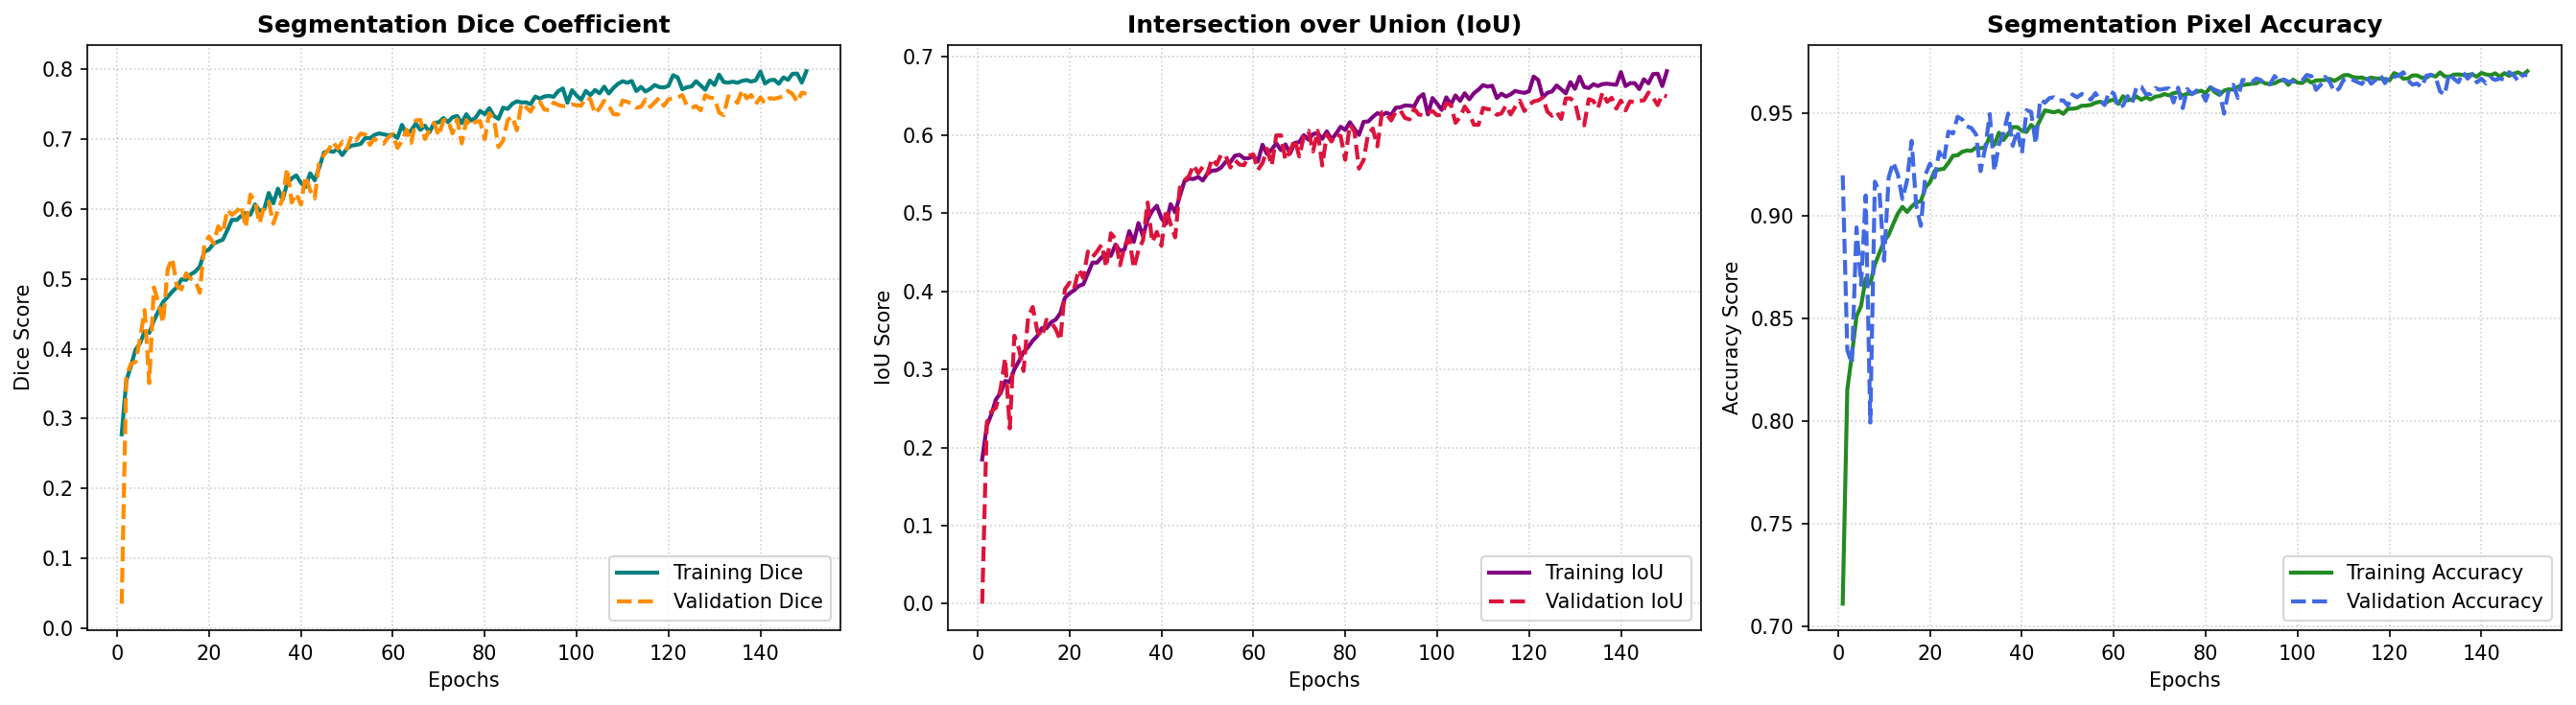

💾 Saved: segmentation_train_val_metrics04.png


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# 📈 PHASE 1: SEGMENTATION LEARNING CURVES (TRAIN VS VALIDATION) - DYNAMIC FIX
# ─────────────────────────────────────────────────────────────────────────────
print("\n📈 [Visuals] Plotting Phase-1 Segmentation History (Train vs Val)...")
history_dict = history_p1.history 
epochs_range = range(1, len(history_dict['loss']) + 1)

dice_key = [k for k in history_dict.keys() if 'dice' in k and 'val' not in k][0]
val_dice_key = [k for k in history_dict.keys() if 'dice' in k and 'val' in k][0]

iou_key = [k for k in history_dict.keys() if 'iou' in k and 'val' not in k][0]
val_iou_key = [k for k in history_dict.keys() if 'iou' in k and 'val' in k][0]


acc_key = [k for k in history_dict.keys() if ('acc' in k or 'accuracy' in k) and 'val' not in k and 'dice' not in k and 'iou' not in k][0]
val_acc_key = [k for k in history_dict.keys() if ('acc' in k or 'accuracy' in k) and 'val' in k and 'dice' not in k and 'iou' not in k][0]

print(f"📊 Mapping Keys Automatically -> Dice: '{dice_key}', IoU: '{iou_key}', Accuracy: '{acc_key}'")

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), dpi=150)

# 1. Dice Coefficient Curve (Train vs Val)
axes[0].plot(epochs_range, history_dict[dice_key], color='teal', lw=2, label='Training Dice')
axes[0].plot(epochs_range, history_dict[val_dice_key], color='darkorange', lw=2, linestyle='--', label='Validation Dice')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].set_title('Segmentation Dice Coefficient', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Dice Score', fontsize=10)
axes[0].legend(loc='lower right')

# 2. IoU Metric Curve (Train vs Val)
axes[1].plot(epochs_range, history_dict[iou_key], color='purple', lw=2, label='Training IoU')
axes[1].plot(epochs_range, history_dict[val_iou_key], color='crimson', lw=2, linestyle='--', label='Validation IoU')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].set_title('Intersection over Union (IoU)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=10)
axes[1].set_ylabel('IoU Score', fontsize=10)
axes[1].legend(loc='lower right')

# 3. Pixel Accuracy Curve (Train vs Val)
axes[2].plot(epochs_range, history_dict[acc_key], color='forestgreen', lw=2, label='Training Accuracy')
axes[2].plot(epochs_range, history_dict[val_acc_key], color='royalblue', lw=2, linestyle='--', label='Validation Accuracy')
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].set_title('Segmentation Pixel Accuracy', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epochs', fontsize=10)
axes[2].set_ylabel('Accuracy Score', fontsize=10)
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()
print("💾 Saved: segmentation_train_val_metrics04.png")


📈 [Visuals] Plotting Phase-2 Classification Loss (Train vs Val)...


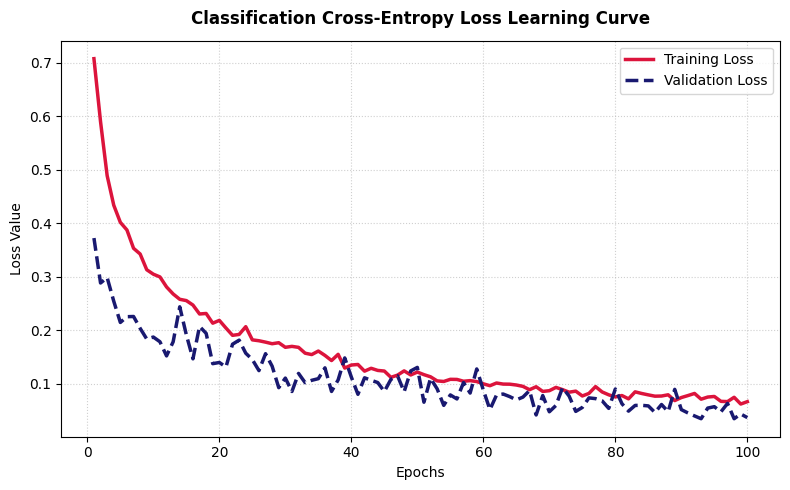

💾 Saved: classification_train_val_loss.png


In [28]:
import matplotlib.pyplot as plt

print("\n📈 [Visuals] Plotting Phase-2 Classification Loss (Train vs Val)...")
h2_dict = history_p2.history
epochs_p2 = range(1, len(h2_dict['loss']) + 1)

p2_loss = [k for k in h2_dict.keys() if 'loss' in k and 'val' not in k][0]
p2_val_loss = [k for k in h2_dict.keys() if 'loss' in k and 'val' in k][0]


plt.figure(figsize=(8, 5), dpi=100)
plt.plot(epochs_p2, h2_dict[p2_loss], color='crimson', lw=2.5, label='Training Loss')
plt.plot(epochs_p2, h2_dict[p2_val_loss], color='midnightblue', lw=2.5, linestyle='--', label='Validation Loss')


plt.title('Classification Cross-Entropy Loss Learning Curve', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("💾 Saved: classification_train_val_loss.png")

In [29]:
print(list(history_p2.history.keys()))

['loss', 'val_loss']


### Testing the Model Phase 1 + Phase 2

⏳ Loading Keras Architecture Graph into Memory (Shared Nodes)...
✅ Multi-Task Graph successfully initialized.

🎬 Processing Positive Dataset Specimen...
🏆 Qualitative evaluation plot successfully saved to: thesis_positive_result.png


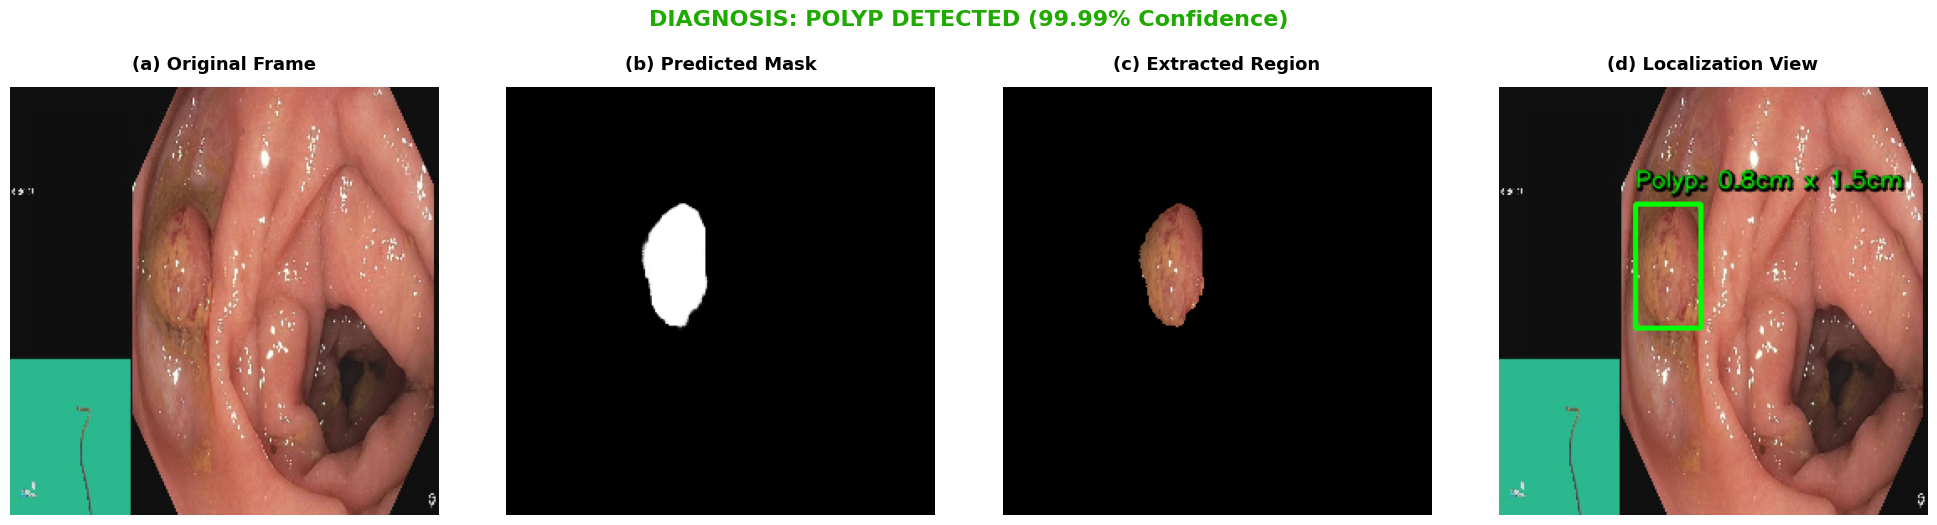


🎬 Processing Negative Dataset Specimen...
🏆 Qualitative evaluation plot successfully saved to: thesis_negative_result.png


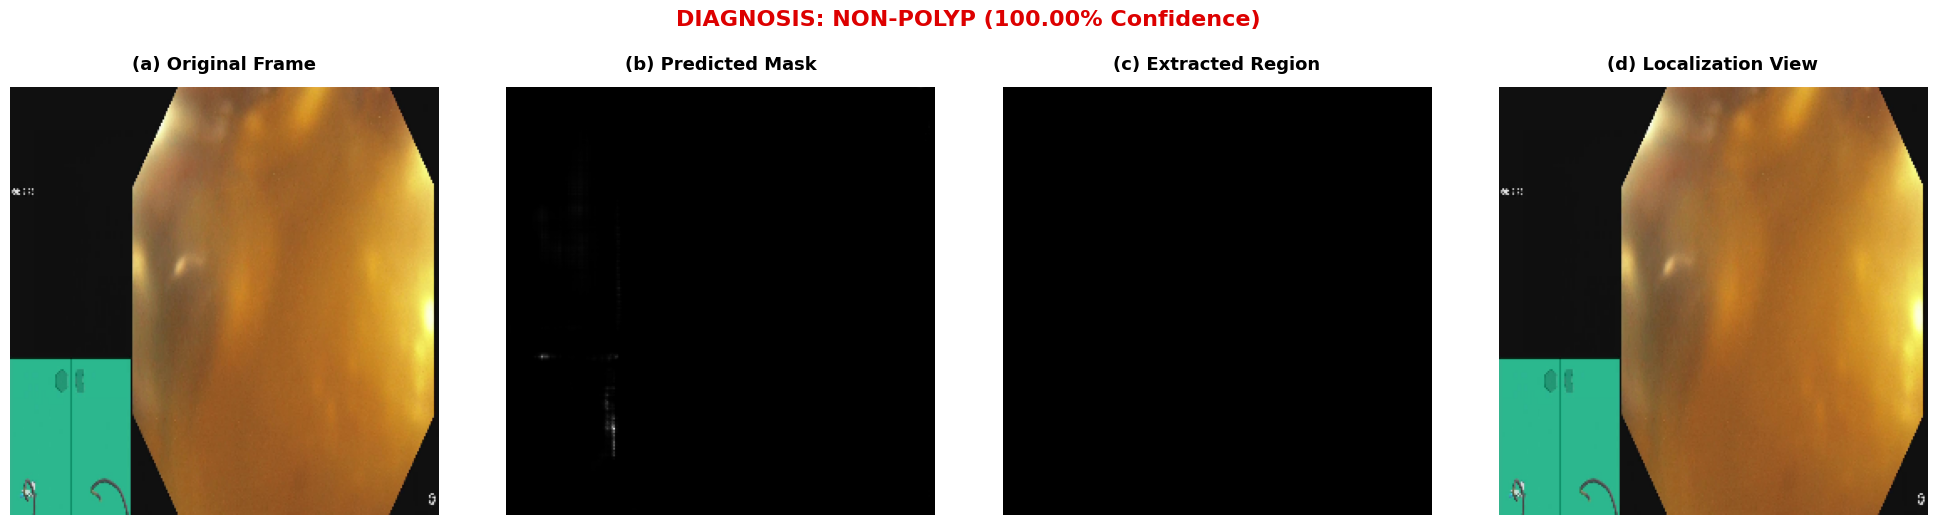


🎬 Processing Negative Dataset Specimen...
🏆 Qualitative evaluation plot successfully saved to: Neg3.png


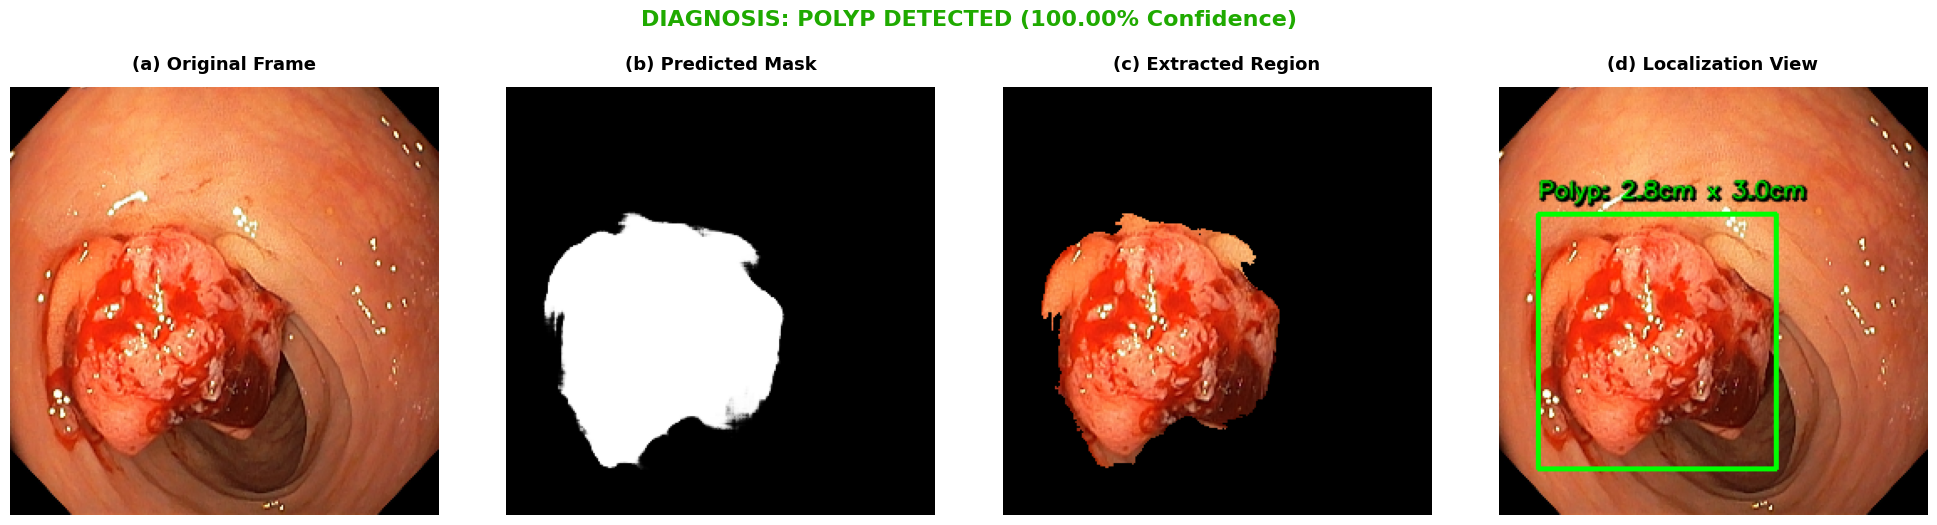


🎬 Processing Negative Dataset Specimen...
🏆 Qualitative evaluation plot successfully saved to: Neg4.png


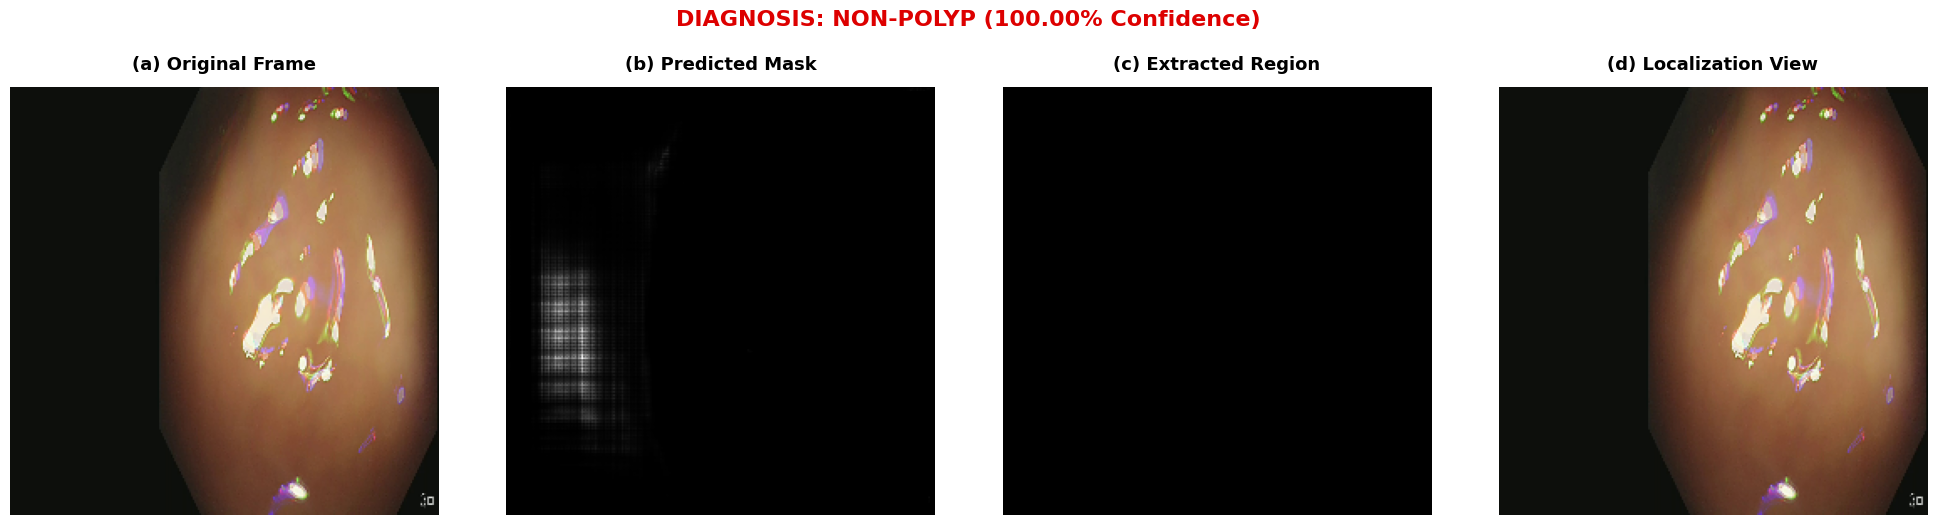

In [35]:
%matplotlib inline

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# ⚙️ GLOBAL INFERENCE CONFIGURATIONS
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE = 256

# Define your exact paths here
MODEL_PATH =  "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/SC/unified_net/thesis_v3_sequential_28_5_02_ds_a_.keras"
TEST_POSITIVE_IMAGE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/data_C4/images_C4/16_endocv2021_positive_557.jpg"
TEST_NEG_IMAGE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/sequenceData/negativeOnly/seq10_neg/EndoCV2021_seq10_neg_40_endocv2021_negative_754.jpg"
TEST_POSITIVE_IMAGE_PATH_2 = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/imagesAll_positive/176OLCV1_100H0890.jpg"
TEST_NEG2_IMAGE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/sequenceData/negativeOnly/seq13_neg/EndoCV2021_C5_seq3_246.jpg"
# ─────────────────────────────────────────────────────────────────────────────
# 🎨 REFINED IMAGE LABELED LOCALIZATION ENGINE
# ─────────────────────────────────────────────────────────────────────────────
def draw_bounding_box(image, mask):
    """
    Draws a clean bounding box around the predicted polyp region with 
    high-contrast paper-grade typography and dimension mapping.
    """
    res_img = image.copy()
    mask_uint8 = (mask > 0.5).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Calibration ratio: mapping image pixels to physical centimeters
    pixel_to_cm_ratio = 50 
    
    for cnt in contours:
        # Filter out minor noise elements or artifacts
        if cv2.contourArea(cnt) < 10:
            continue
            
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Calculate real-world scale approximations
        width_cm = w / pixel_to_cm_ratio
        height_cm = h / pixel_to_cm_ratio
        size_text = f"Polyp: {width_cm:.1f}cm x {height_cm:.1f}cm"
        
        # 1. Draw High-Visibility Bounding Box (Green)
        cv2.rectangle(res_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # 2. Advanced Typography: Dynamic Text Positioning with Background Shadow
        text_y = y - 10 if y - 10 > 20 else y + h + 20
        
        # Draw a clean black backdrop shadow for ultra-clear readability in papers
        cv2.putText(res_img, size_text, (x + 1, text_y + 1), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 2, cv2.LINE_AA)
        # Draw the primary text layer
        cv2.putText(res_img, size_text, (x, text_y), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1, cv2.LINE_AA)
        
    return res_img

# ─────────────────────────────────────────────────────────────────────────────
# 🔮 MULTI-TASK INFERENCE CORE PIPELINE (SEGMENTATION + CLASSIFICATION)
# ─────────────────────────────────────────────────────────────────────────────
# 🔮 MULTI-TASK INFERENCE CORE PIPELINE (🎯 FIXED FOR 5-HEAD DEEP SUPERVISION)
def test_and_display(model, image_path, output_filename='result.png'):
    """
    Executes a joint multi-task prediction, extracting both pixel-level 
    segmentation masks and categorical classification diagnostic boundaries.
    """
    # 1. Read and pre-process target frame
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"❌ Target frame could not be loaded at: {image_path}")
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    inp = np.expand_dims(img_res / 255.0, axis=0).astype(np.float32)

    # 2. Target forward pass prediction (Extracting multi-head lists)
    pred_outputs = model.predict(inp, verbose=0)
    
    # 🎯 ফিক্স: আপনার ৫-হেড বিশিষ্ট মডেলের আউটপুট সঠিকভাবে হ্যান্ডেল করা
    if isinstance(pred_outputs, list) and len(pred_outputs) == 5:
        pred_mask_spatial = pred_outputs[0][0]  # Output Index 0: মেইন সেগমেন্টেশন মাস্ক [256, 256, 1]
        
        # ৫ নম্বর পজিশন (Index 4) হলো আসল ক্লাসিফিকেশন হেড ('clf_output')
        # কেরালা আউটপুট ফরম্যাট থেকে স্কেলার ভ্যালু বের করার জন্য .numpy() বা ফ্ল্যাট ইন্ডেক্সিং ব্যবহার
        clf_out_raw = pred_outputs[4][0]
        clf_prediction = float(clf_out_raw[0]) if hasattr(clf_out_raw, '__len__') else float(clf_out_raw)
        has_classification = True
        
    elif isinstance(pred_outputs, list) and len(pred_outputs) >= 2:
        # ওল্ড ২-হেড মডেল ব্যাকআপ (যদি কখনো আগের মডেল লোড করেন)
        pred_mask_spatial = pred_outputs[0][0]
        clf_out_raw = pred_outputs[1][0]
        clf_prediction = float(clf_out_raw[0]) if hasattr(clf_out_raw, '__len__') else float(clf_out_raw)
        has_classification = True
    else:
        # ফলব্যাক (শুধু সেগমেন্টেশন মোড)
        pred_mask_spatial = pred_outputs[0] if isinstance(pred_outputs, list) else pred_outputs[0]
        if len(pred_mask_spatial.shape) == 4:  # batch dimension হ্যান্ডেল করতে
            pred_mask_spatial = pred_mask_spatial[0]
        clf_prediction = 0.0
        has_classification = False

    # 3. Geometric extraction mappings
    mask_bin = (pred_mask_spatial > 0.5).astype(np.uint8)
    mask_3d = np.concatenate([mask_bin] * 3, axis=-1)
    extracted = (img_res * mask_3d).astype(np.uint8)
    detected_img = draw_bounding_box(img_res, pred_mask_spatial)

    # 4. Generate Dynamically Labeled Classification Title
    if has_classification:
        if clf_prediction >= 0.5:
            diagnostic_text = f"DIAGNOSIS: POLYP DETECTED ({clf_prediction * 100:.2f}% Confidence)"
            title_color = '#1faa00' # Vibrant Green
        else:
            diagnostic_text = f"DIAGNOSIS: NON-POLYP ({(1.0 - clf_prediction) * 100:.2f}% Confidence)"
            title_color = '#dd0000' # Deep Red
    else:
        diagnostic_text = "DIAGNOSIS: Segmentation Mode Active (No Classification Head Found)"
        title_color = 'orange'

    # 5. Generate Professional 4-Column Presentation Graph
    titles = ['(a) Original Frame', '(b) Predicted Mask', '(c) Extracted Region', '(d) Localization View']
    display_images = [img_res, pred_mask_spatial.squeeze(), extracted, detected_img]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for i in range(4):
        axes[i].imshow(display_images[i], cmap='gray' if i == 1 else None)
        axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=12)
        axes[i].axis('off')
    
    # High-level overview structural description super-title with live diagnosis
    plt.suptitle(diagnostic_text, fontsize=16, fontweight='bold', color=title_color, y=1.04)
    
    plt.tight_layout()
    
    # Save the polished output image to disk
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"🏆 Qualitative evaluation plot successfully saved to: {output_filename}")
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 🏃‍♂️ EXECUTION STEP
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    print("⏳ Loading Keras Architecture Graph into Memory (Shared Nodes)...")
    # Load model once outside the function to optimize execution loop
    shared_model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("✅ Multi-Task Graph successfully initialized.\n")
    
    print("🎬 Processing Positive Dataset Specimen...")
    test_and_display(shared_model, TEST_POSITIVE_IMAGE_PATH, 'thesis_positive_result.png')
    
    print("\n🎬 Processing Negative Dataset Specimen...")
    test_and_display(shared_model, TEST_NEG_IMAGE_PATH, 'thesis_negative_result.png')

    print("\n🎬 Processing Negative Dataset Specimen...")
    test_and_display(shared_model, TEST_POSITIVE_IMAGE_PATH_2,'Neg3.png')

    print("\n🎬 Processing Negative Dataset Specimen...")
    test_and_display(shared_model, TEST_NEG2_IMAGE_PATH,'Neg4.png')


#### Performance Matrix

In [37]:
# =============================================================================
# 📊 PRINT PEAK PERFORMANCE METRICS FOR THESIS REPORT
# =============================================================================
print("=====================================================================")
print("🏆 Unified Model: Peak Performance Metrics (Phase 1 & Phase 2)")
print("=====================================================================")

# 🧠 1. PHASE 1: SEMANTIC SEGMENTATION PERFORMANCE
h1 = history_p1.history


dice_key = [k for k in h1.keys() if 'dice' in k and 'val' not in k][0]
val_dice_key = [k for k in h1.keys() if 'dice' in k and 'val' in k][0]
iou_key = [k for k in h1.keys() if 'iou' in k and 'val' not in k][0]
val_iou_key = [k for k in h1.keys() if 'iou' in k and 'val' in k][0]


acc_key = [k for k in h1.keys() if ('acc' in k or 'accuracy' in k) and 'val' not in k][0]
val_acc_key = [k for k in h1.keys() if ('acc' in k or 'accuracy' in k) and 'val' in k][0]
rec_key = [k for k in h1.keys() if 'recall' in k and 'val' not in k][0]
val_rec_key = [k for k in h1.keys() if 'recall' in k and 'val' in k][0]
tnr_key = [k for k in h1.keys() if 'tnr' in k and 'val' not in k][0]
val_tnr_key = [k for k in h1.keys() if 'tnr' in k and 'val' in k][0]


best_p1_idx = np.argmax(h1[val_dice_key])

print(f"\n📍 [PHASE 1: SEGMENTATION (Best Epoch: {best_p1_idx + 1})]")
print(f"   • Best Training Dice Score    : {h1[dice_key][best_p1_idx]:.4f}")
print(f"   • Best Validation Dice Score  : {h1[val_dice_key][best_p1_idx]:.4f} 🌟")
print(f"   • Associated Training IoU     : {h1[iou_key][best_p1_idx]:.4f}")
print(f"   • Associated Validation IoU   : {h1[val_iou_key][best_p1_idx]:.4f}")

print(f"   • Associated Training Acc     : {h1[acc_key][best_p1_idx]:.4f}")
print(f"   • Associated Validation Acc   : {h1[val_acc_key][best_p1_idx]:.4f}")
print(f"   • Associated Training Recall  : {h1[rec_key][best_p1_idx]:.4f}")
print(f"   • Associated Validation Recall: {h1[val_rec_key][best_p1_idx]:.4f}")
print(f"   • Associated Training TNR     : {h1[tnr_key][best_p1_idx]:.4f}")
print(f"   • Associated Validation TNR   : {h1[val_tnr_key][best_p1_idx]:.4f}")


# 🧠 2. PHASE 2: CLASSIFICATION PERFORMANCE

h2 = history_p2.history
best_p2_idx = np.argmin(h2['val_loss'])

print(f"\n📍 [PHASE 2: CLASSIFICATION (Best Epoch: {best_p2_idx + 1})]")
print(f"   • Minimum Training Loss       : {h2['loss'][best_p2_idx]:.4f}")
print(f"   • Minimum Validation Loss     : {h2['val_loss'][best_p2_idx]:.4f} 🌟")

p2_acc_keys = [k for k in h2.keys() if 'acc' in k or 'accuracy' in k]
if p2_acc_keys:
    acc_k = [k for k in p2_acc_keys if 'val' not in k][0]
    val_acc_k = [k for k in p2_acc_keys if 'val' in k][0]
    print(f"   • Peak Training Accuracy      : {h2[acc_k][best_p2_idx]:.4f}")
    print(f"   • Peak Validation Accuracy    : {h2[val_acc_k][best_p2_idx]:.4f}")
else:
    print("   • Note: Accuracy metrics were dropped in Phase 2 compile for this run.")

print("=====================================================================")


🏆 Unified Model: Peak Performance Metrics (Phase 1 & Phase 2)

📍 [PHASE 1: SEGMENTATION (Best Epoch: 136)]
   • Best Training Dice Score    : 0.7832
   • Best Validation Dice Score  : 0.7702 🌟
   • Associated Training IoU     : 0.6653
   • Associated Validation IoU   : 0.6547
   • Associated Training Acc     : 0.9684
   • Associated Validation Acc   : 0.9697
   • Associated Training Recall  : 0.8251
   • Associated Validation Recall: 0.8231
   • Associated Training TNR     : 0.9810
   • Associated Validation TNR   : 0.9823

📍 [PHASE 2: CLASSIFICATION (Best Epoch: 93)]
   • Minimum Training Loss       : 0.0708
   • Minimum Validation Loss     : 0.0343 🌟
   • Note: Accuracy metrics were dropped in Phase 2 compile for this run.


#### Model Summary

In [38]:
model.summary()

Model: "Thesis_DeepSupervised_YNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ shared_input_image  │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c1_3x3          │ (None, 256, 256,  │         51 │ shared_input_ima… │
│ (SeparableConv2D)   │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c1_5x5          │ (None, 256, 256,  │         99 │ shared_input_ima… │
│ (SeparableConv2D)   │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c1_7x7          │ (None, 256, 256,  │        171 │ shared_input_ima… │
│ (SeparableConv2D)   │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c1_1x1          │ (None, 256, 256,  │         27 │ shared_input_ima… │
│ (SeparableConv2D)   │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │         32 │ enc_c1_3x3[0][0]  │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         32 │ enc_c1_5x5[0][0]  │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         32 │ enc_c1_7x7[0][0]  │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         32 │ enc_c1_1x1[0][0]  │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c1_concat       │ (None, 256, 256,  │          0 │ activation[0][0], │
│ (Concatenate)       │ 32)               │            │ activation_1[0][… │
│                     │                   │            │ activation_2[0][… │
│                     │                   │            │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ enc_c1_concat[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         64 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,495,433 (5.70 MB)

 Trainable params: 88,737 (346.63 KB)

 Non-trainable params: 1,229,216 (4.69 MB)

 Optimizer params: 177,480 (693.29 KB)

#### Image Segmentation Time

In [39]:
import time
import numpy as np
import tensorflow as tf

sample_images, _ = next(iter(val_seg_ds.take(1))) 
sample_images = sample_images[:5] 

print("⚡ Running GPU Warm-up iterations...")
for _ in range(2):
    _ = model.predict(sample_images[0:1], verbose=0)

print("⏱️ Measuring exact inference time per image...")
execution_times = []

for i in range(len(sample_images)):
    single_img = tf.expand_dims(sample_images[i], axis=0) # Shape: (1, 256, 256, 3)
    
    start_time = time.perf_counter()
    

    outputs = model.predict(single_img, verbose=0)
    

    _ = tf.cast(outputs[0], tf.float32) 
    
    end_time = time.perf_counter()
    
    elapsed_time = (end_time - start_time) * 1000 
    execution_times.append(elapsed_time)
    print(f"   • Image {i+1}: {elapsed_time:.2f} ms")


avg_time_ms = np.mean(execution_times)
avg_time_sec = avg_time_ms / 1000
fps = 1 / avg_time_sec

print("\n=======================================================")
print("📊 FINAL COMPUTATIONAL EFFICIENCY REPORT")
print("=======================================================")
print(f"🚀 Average Inference Time : {avg_time_ms:.2f} ms per image")
print(f"⏰ In Seconds              : {avg_time_sec:.4f} seconds")
print(f"🎬 Frames Per Second (FPS) : {fps:.2f} FPS 🌟")
print("=======================================================")

⚡ Running GPU Warm-up iterations...
⏱️ Measuring exact inference time per image...
   • Image 1: 70.52 ms
   • Image 2: 91.93 ms
   • Image 3: 99.18 ms
   • Image 4: 73.21 ms

📊 FINAL COMPUTATIONAL EFFICIENCY REPORT
🚀 Average Inference Time : 83.71 ms per image
⏰ In Seconds              : 0.0837 seconds
🎬 Frames Per Second (FPS) : 11.95 FPS 🌟
